# Analiza danych


<span style="color: orange;">Tak, dla uporządkowania, to na pomarańczowo piszę wszystko, co z końcowej wersji powinno zniknąć :) </span>

#### [Zbiór danych zaczerpnięty ze strony www.kaggle.com](https://www.kaggle.com/datasets/shashanks1202/apartment-rent-data).

[Na licencji MIT](https://www.mit.edu/~amini/LICENSE.md)

 Copyright (c) 2013 Mark Otto.</br>
 Copyright (c) 2017 Andrew Fong.

 Zbiór danych zawiera szczegółowe informacje o wynajmie mieszkań w Stanach Zjednoczonych Ameryki. Zawarte w zbiorze dane obejmują ważniejsze informacje dotyczące wynajmu. 
 </BR>Są to :
- kategoria oferowanej nieruchomości,
- lokalizacja (adres, nazwa miasta, stan, szerokość i długość geograficzną), 
- źródło ogłoszenia,
- szczegóły nieruchomości obejmujące informacje o kategorii mieszkania, tytule własności, bryle, udogodnieniach, liczbie łazienek, sypialni i powierzchni mieszkania (w stopach kwadratowych).
- cenę wynajmu (price), 
- cenę wyświetlaną (price_display), 
- typ ceny (price_type)
- Informacja, czy wymagana jest opłata.
- Informacja, czy oferta ma załączone zdjęcie (has_photo),
- Informacja, czy zwierzęta są dozwolone (pets_allowed),
- Waluta (zawsze USD)
- Czas utworzenia oferty.



#### <span style="color: deepskyblue;">Przebieg czyszczenia danych opisany jest w pliku [raport.ipynb](raport.ipynb)    </span>

Analiza jest wykonana dla oczyszczonego pliku [apartments_clean.csv](\data\apartments_clean.csv)

#### <span style="color: deepskyblue;">Analiza dotycząca oferowanych powierzchni nieruchomości w ujęciu geograficznym   </span>



In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns
import plotly.express as px

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")
df.head(1)

/tmp/ipykernel_6700/1124396631.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,4.049815


In [13]:
df_state = pd.read_csv("data/przypisanie_stanowUSA.csv", sep=';', encoding="cp1250")
df_state.head(1)

,Stan,Skrot,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,Alabama,AL,South,CST / EST,Tak,Tak,Nie


In [14]:

# dołącz nazwę stanu
df = df.merge(
    df_state[['Skrot', 'Stan']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz region
df = df.merge(
    df_state[['Skrot', 'Region']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Strefa czasowa
df = df.merge(
    df_state[['Skrot', 'Strefa czasowa']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan rolniczy
df = df.merge(
    df_state[['Skrot', 'Stan rolniczy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan przemyslowy
df = df.merge(
    df_state[['Skrot', 'Stan przemyslowy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Wazny turystycznie
df = df.merge(
    df_state[['Skrot', 'Wazny turystycznie']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')
df.head(2)


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,View,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,0,4.049815,California,West,PST,Tak,Tak,Tak
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak


In [15]:
# na podstawie pól logicznych określam charakter stanu
df['charakter'] = (
    np.where(df['Stan rolniczy']=="Tak", 'Roln ', '') +
    np.where(df['Stan przemyslowy']=="Tak", 'Przem ', '') +
    np.where(df['Wazny turystycznie']=="Tak", 'Turyst', '')
)

df['charakter'] = df['charakter'].str.strip()

df.head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Yes,NaN,1395.0,...,0,0,0.845455,North Carolina,South,EST,Tak,Tak,Tak,Roln Przem Turyst
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Yes,"Cats,Dogs",1600.0,...,0,0,1.951220,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Yes,"Cats,Dogs",975.0,...,0,0,1.562500,New Mexico,West,MST,Nie,Nie,Tak,Turyst


In [16]:
df1 = df[(df["square_feet"] <= 300)]
df1["bin_square_feet"] = pd.cut(
    df1["square_feet"],
    bins=[0, 200, 250, 300, float("inf")],
    labels=["0-200", "200-250", "250-300", "300+"]
)
#df1.head(3)
#df1.to_csv('D:\\tmp\\df1.csv', sep=';', index=False, encoding='utf-8')

/tmp/ipykernel_6700/1388438337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["bin_square_feet"] = pd.cut(


In [17]:
df2 = df[(df["square_feet"] > 300) & ( df["square_feet"] <= 2100) ]
df2["bin_square_feet"] = pd.cut(
    df2["square_feet"],
    bins=[300,500, 700, 1000, 1500, 2000, 2100, float("inf")],
    labels=["do 500", " do 700", " do 1000", "do 1500",
            " do 2000","do 2100", "2100+"]
)
#df2.head(3)

/tmp/ipykernel_6700/1251662969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["bin_square_feet"] = pd.cut(


In [18]:
df3 = df[(df["square_feet"] > 2100)]
df3["bin_square_feet"] = pd.cut(
    df3["square_feet"],
    bins=[2100,2500,3000, 4000, 5000, 10000, float("inf")],
    labels=["do 2500", " do 3000", " do 4000", "do 5000","do 10000", "10000+"]
)
#df3.head(3)

/tmp/ipykernel_6700/2301134814.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["bin_square_feet"] = pd.cut(


In [19]:
df["bin_square_feet"] = pd.cut(
    df["square_feet"],
    bins=[300, 500, 700, 1000, 1500, 2000, 2500, float("inf")],
    labels=["0-300", "300-500", "500-700", "700-1000", "1000-1500","1500-2000","2000-2500"]
)
df.head(2)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter,bin_square_feet
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst,300-500
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst,700-1000


#### Rozkład wartości powierzchni według Regionu USA dla różnych grup nieruchomości

In [21]:
# Wykres na którym na osi x będzie charakter, na osi y przedział_powierzchni, 
# kolorem określony stan, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres

region_colors = {
    "Northeast": "green",
    "Midwest": "yellow",
    "South": "orange",
    "West": "lightgreen"
}
charakter_colors = {
    "Roln": "green",
    "Roln Przem": "darkolivegreen",
    "Roln Przem Turyst": "lightgreen",
    "Roln Turyst": "darkgoldenrod",
    "Przem":"brown",
    "Przem Turyst": "darkorange",
    "Turyst": "yellow",
    "": "skyblue"
}
fig = px.scatter(
    agg,
    x="charakter",
    y="bin_square_feet",
    color="Region",
    color_discrete_map=region_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni i Regionu USA"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


/tmp/ipykernel_6700/337075666.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Uszczegółowienie powyższego wykresu dla grup ofert o powierzchni małej, sredniej i dużej.

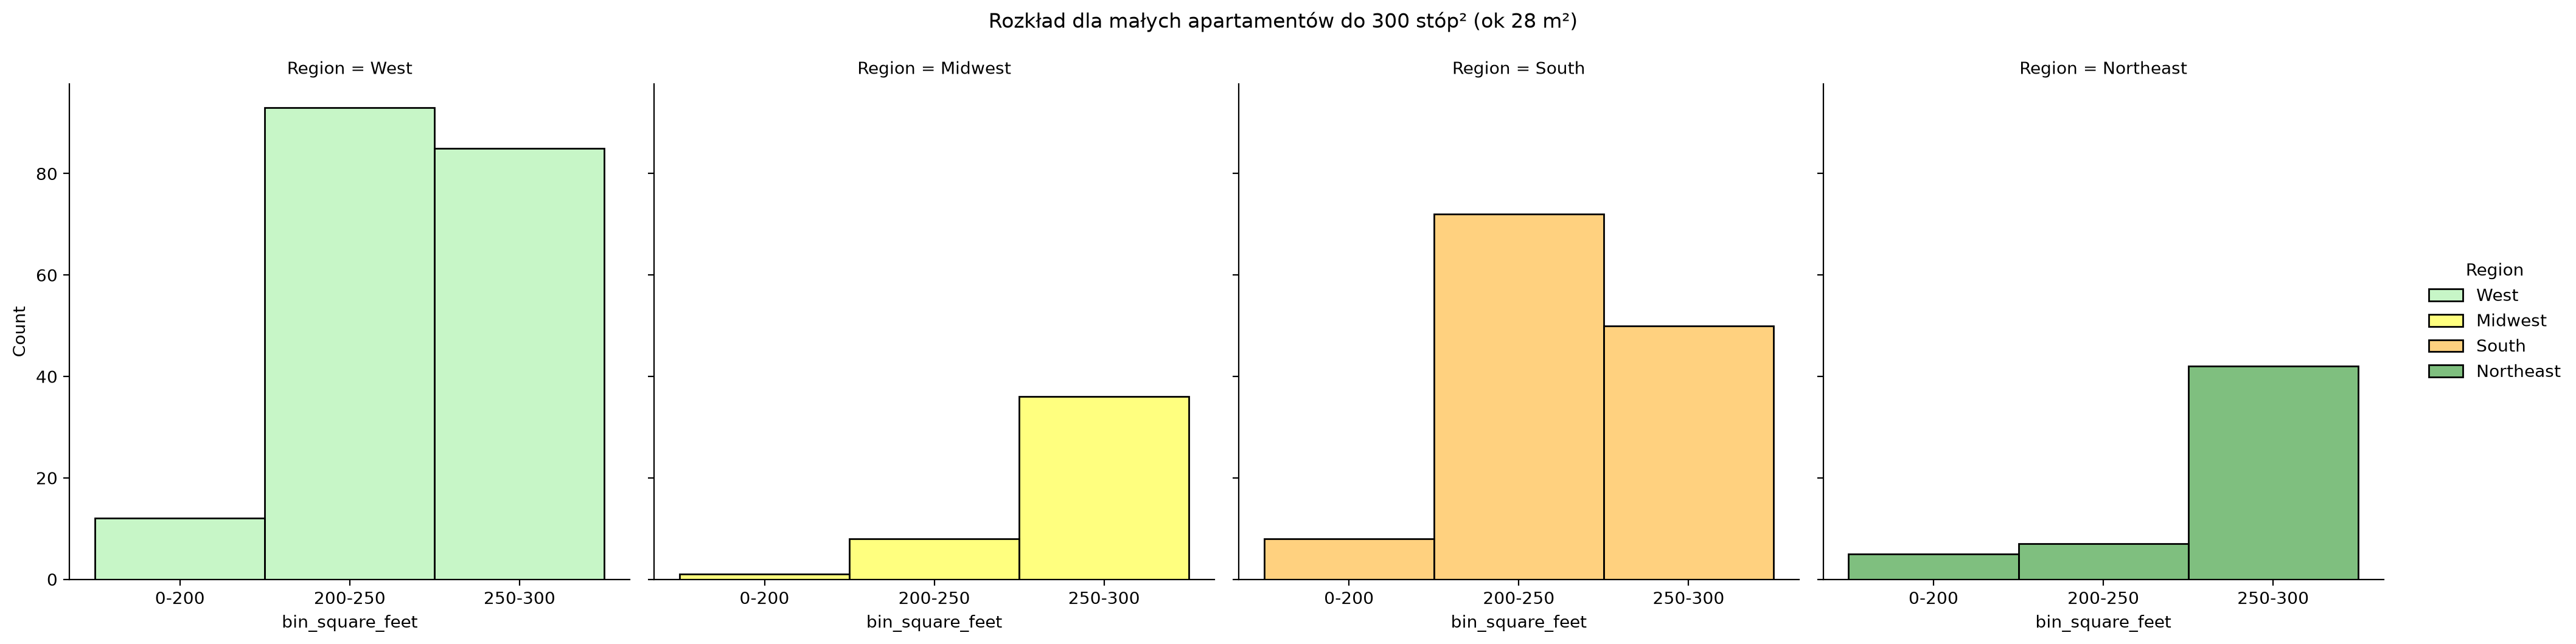

In [ ]:
sns.displot(
    data=df1,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)
plt.suptitle("Rozkład dla małych apartamentów do 300 stóp² (ok 28 m²)", y=1.05)
plt.show()

Widoczna zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

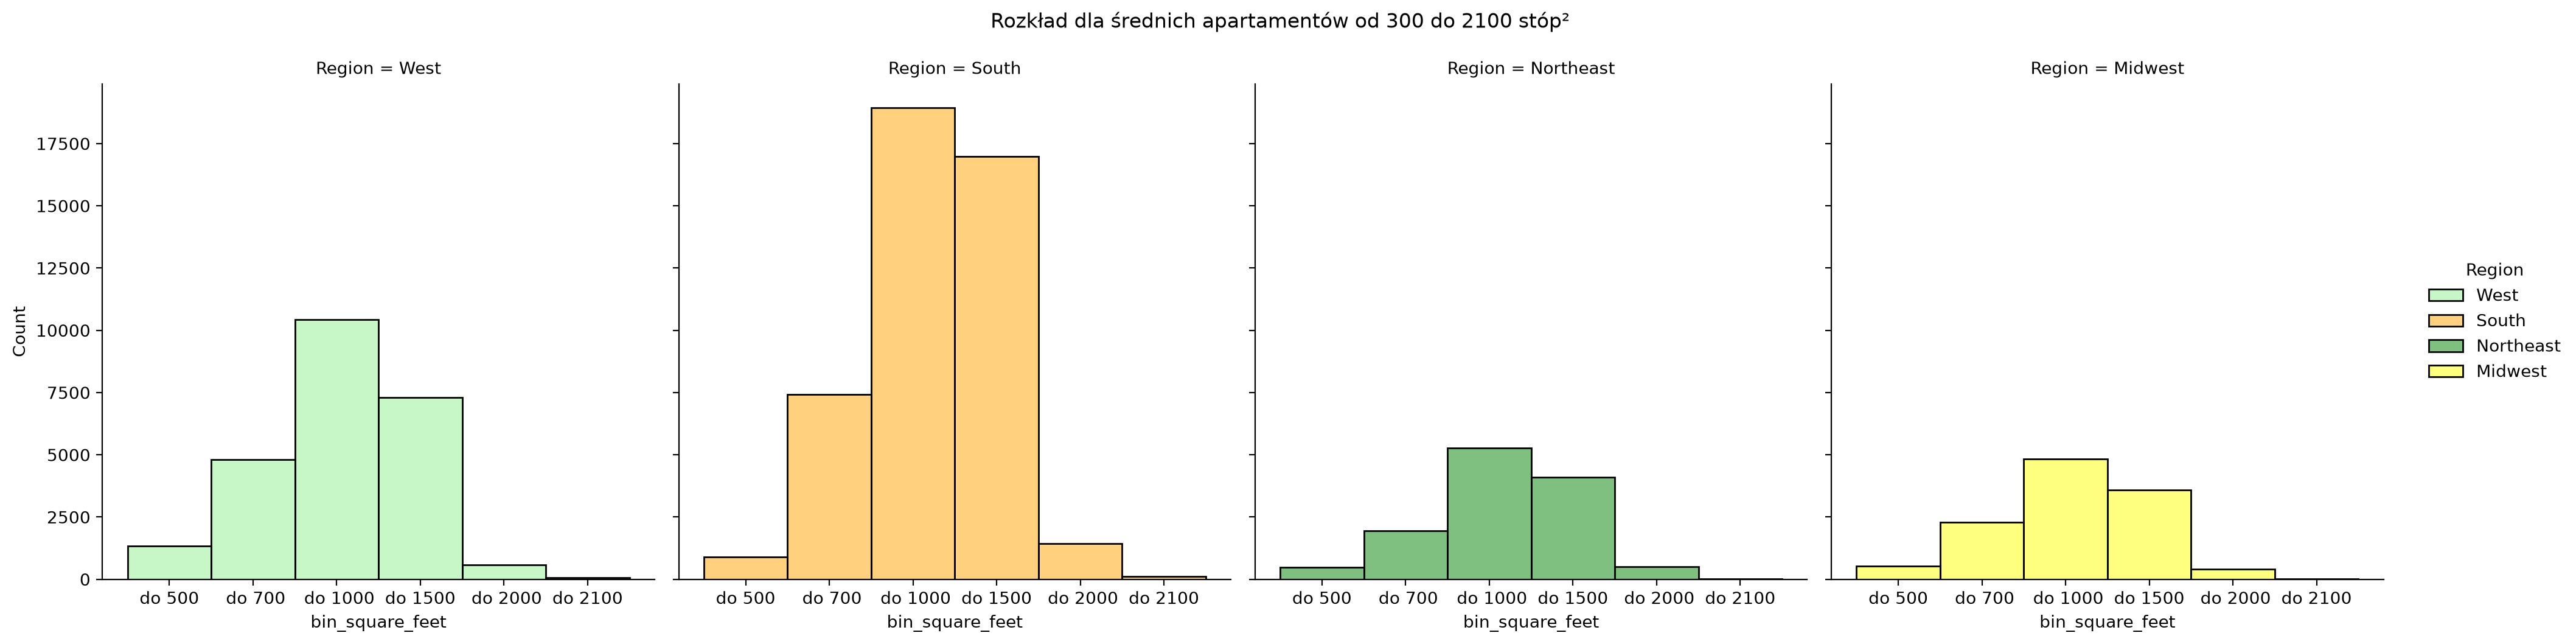

In [ ]:
sns.displot(
    data=df2,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla średnich apartamentów od 300 do 2100 stóp² ", y=1.05)
plt.show()


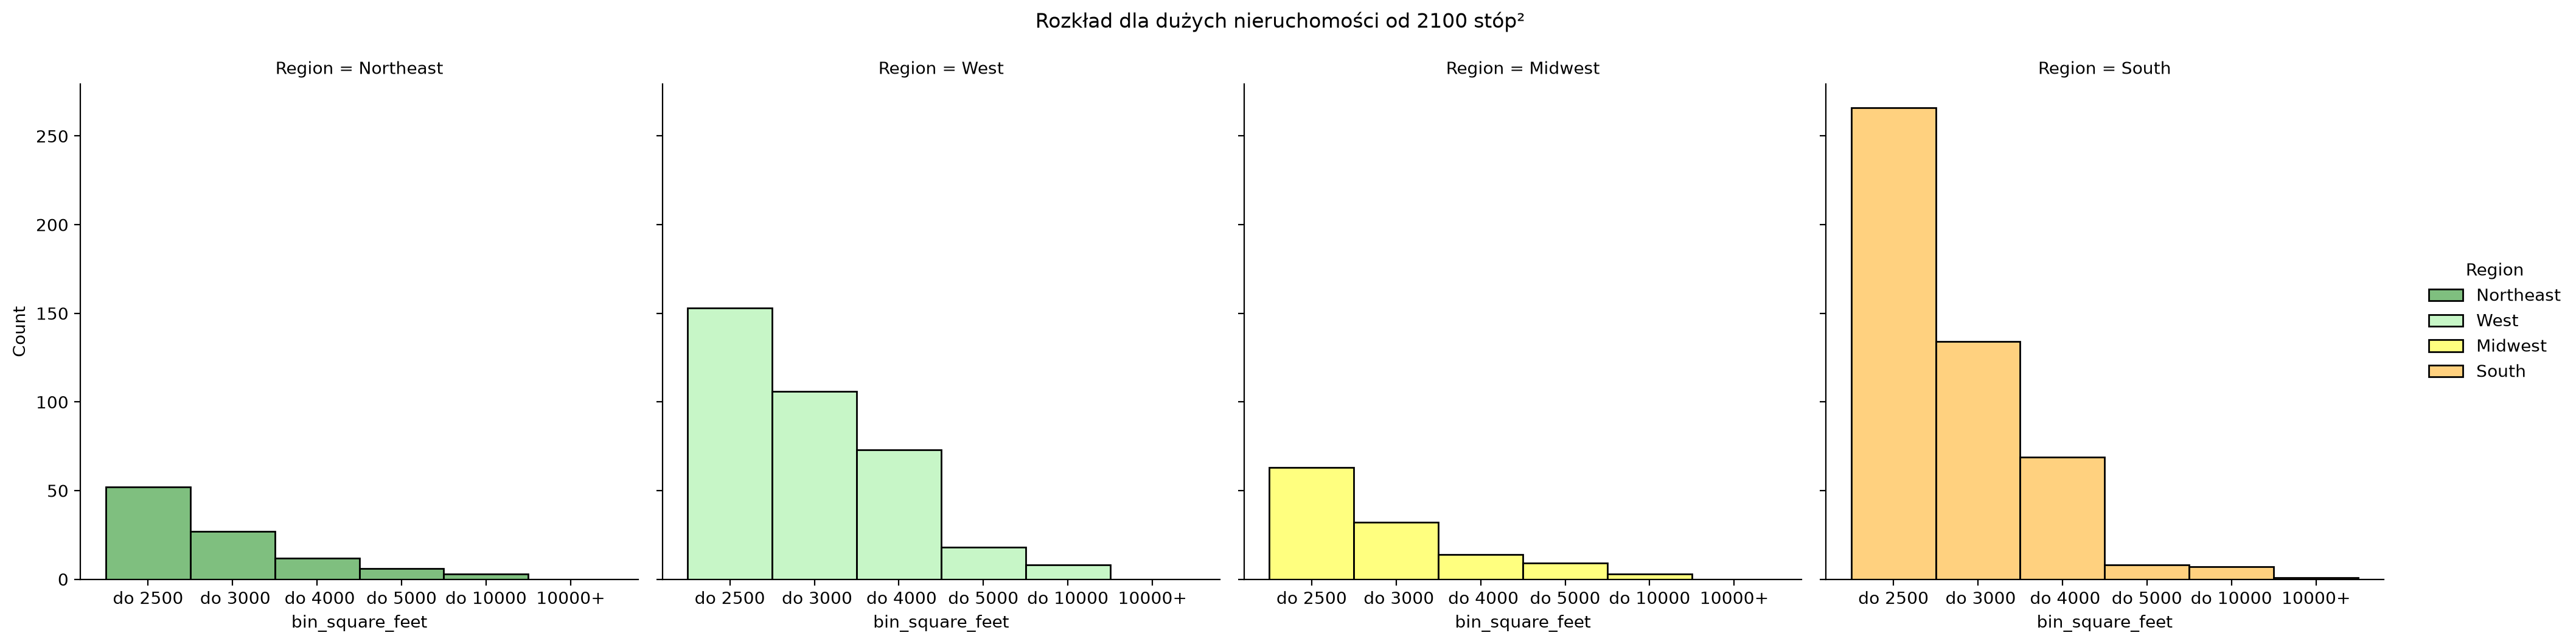

In [ ]:
sns.displot(
    data=df3,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla dużych nieruchomości od 2100 stóp² ", y=1.05)
plt.show()

In [ ]:
# wykres na którym na osi x będzie region, na osi y przedział_powierzchni, 
# kolorem określony charakter, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres
fig = px.scatter(
    agg,
    x="Region",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
             "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg Regionu USA, przedziału powierzchni i charakteru"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


In [ ]:
df_West = df[(df["Region"] == "West")]

df_West.head(3)
agg_West = (
    df_West.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_West,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu West USA"
)

fig.update_layout()



In [ ]:
df_South = df[(df["Region"] == "South")]

df_South.head(3)
agg_South = (
    df_South.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_South,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu South USA"
)

fig.update_layout()



In [ ]:
df_Northeast = df[(df["Region"] == "Northeast")]

df_Northeast.head(3)
agg_Northeast = (
    df_Northeast.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Northeast,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Northeast USA"
)

fig.update_layout()


In [ ]:
df_Midwest = df[(df["Region"] == "Midwest")]

df_Midwest.head(3)
agg_Midwest = (
    df_Midwest.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Midwest,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Midwest USA"
)

fig.update_layout()

#### Interpretacja wyniku

Wykresy obrazują charakter różnych regionów i stanów zgodnie z dołączonym mapowanim. 
Nie widać dużej zależności powierzchni oferowanych nieruchomości od charakteru stanu. Najwięcej ofert jest w przedziale nieruchomości średnich niezależnie od regionu. 

Wcześniej w tekście przy wykresie dotyczącym małych nieruchomości wskazano zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

#### <span style="color: deepskyblue;">Analiza dotycząca ogólnego rozkładu cen  </span>



Liczba ofert: 95771
Średnia cena: 1530.90 USD
Mediana ceny: 1355.00 USD
Odchylenie standardowe: 872.60 USD
Przedział kwartylowy (IQR): 1022.00 USD - 1795.00 USD


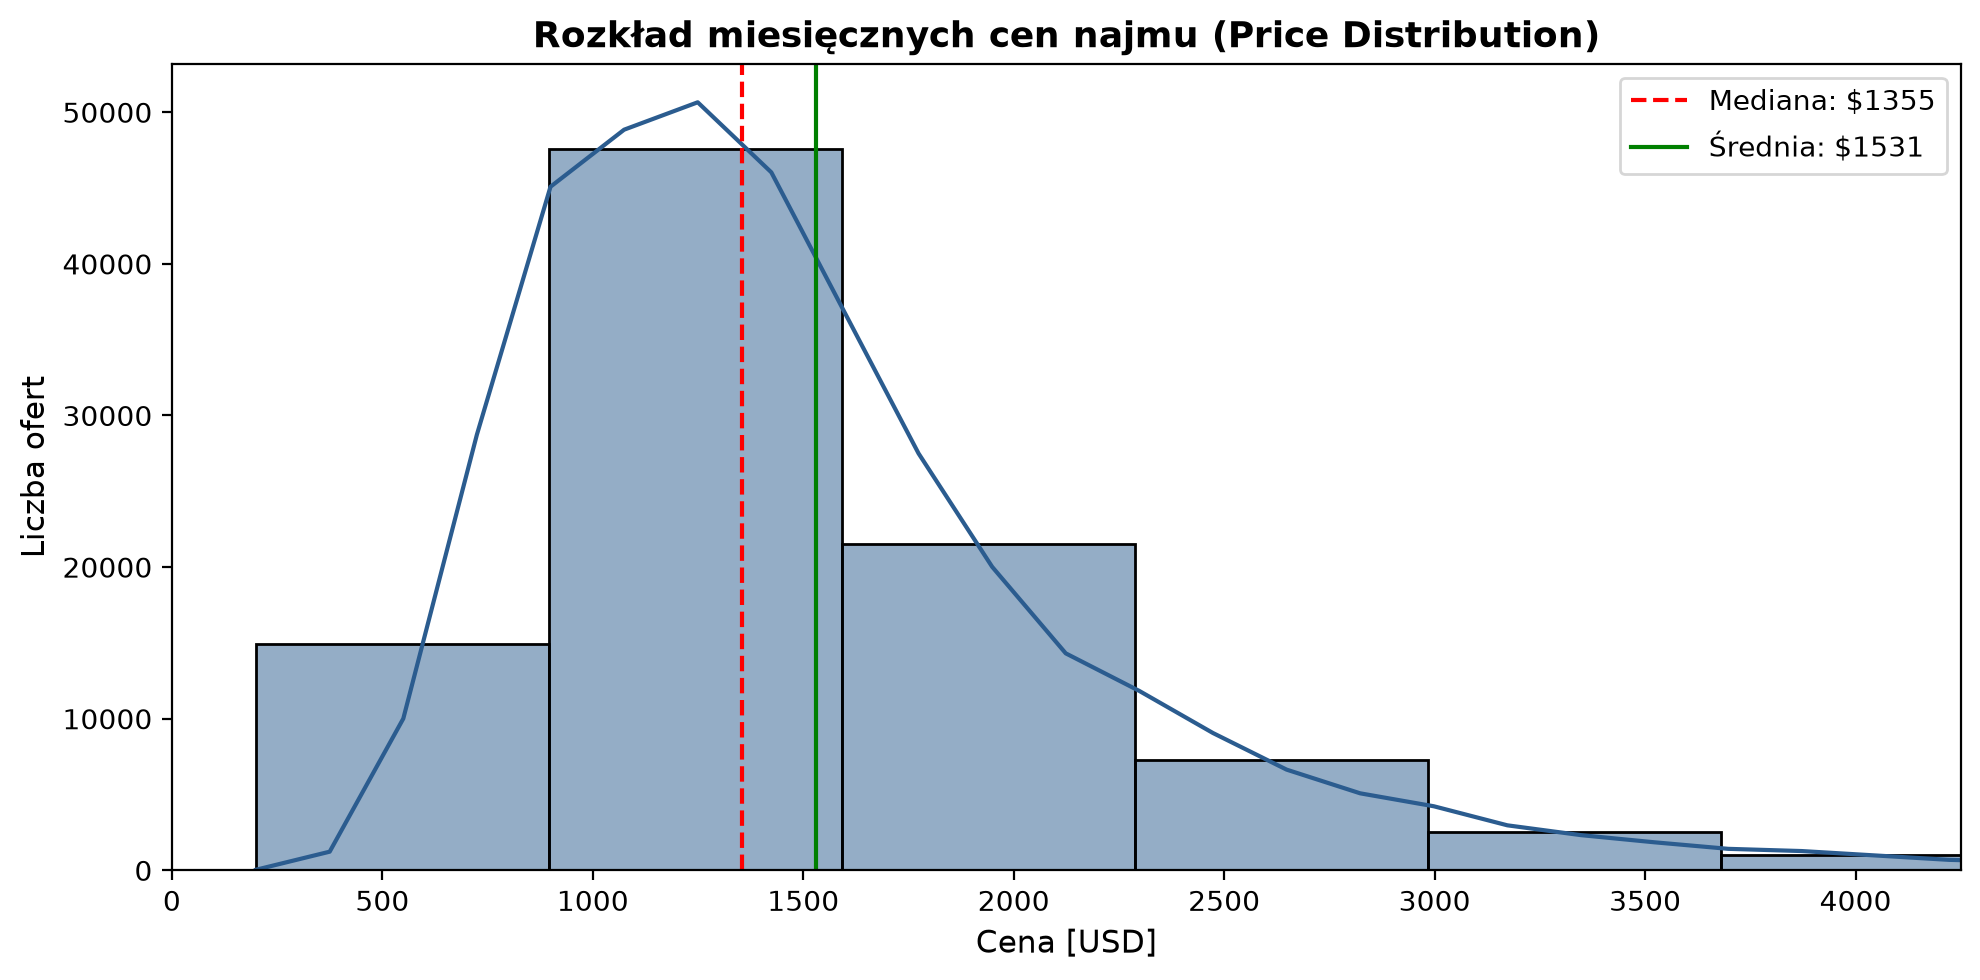

In [31]:
df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250", low_memory=False)

# Wyliczenie statystyk
srednia = df['price'].mean()
mediana = df['price'].median()
std_dev = df['price'].std()
kwartyl_25 = df['price'].quantile(0.25)
kwartyl_75 = df['price'].quantile(0.75)

print(f'Liczba ofert: {len(df)}')
print(f'Średnia cena: {srednia:.2f} USD')
print(f'Mediana ceny: {mediana:.2f} USD')
print(f'Odchylenie standardowe: {std_dev:.2f} USD')
print(f'Przedział kwartylowy (IQR): {kwartyl_25:.2f} USD - {kwartyl_75:.2f} USD')

# Wizualizacja rozkładu
plt.figure(figsize=(10, 5))
sns.histplot(
    df['price'], bins=50, kde=True, color='#2b5c8f', edgecolor='black'
)

# Tytuł i etykiety osi
plt.title(
    'Rozkład miesięcznych cen najmu (Price Distribution)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Cena [USD]', fontsize=11)
plt.ylabel('Liczba ofert', fontsize=11)

# Ograniczenie widoku osi X do 99. percentyla dla czytelności
plt.xlim(0, df['price'].quantile(0.99))

# Linie reprezentujące średnią oraz medianę
plt.axvline(
    mediana, color='red', linestyle='--', label=f'Mediana: ${mediana:.0f}'
)
plt.axvline(srednia, color='green', linestyle='-', label=f'Średnia: ${srednia:.0f}')

plt.legend()
plt.tight_layout()
plt.show()

 10 udogodnien pod wzgledem wplywu na cene 
Udogodnienie  Liczba_ofert  Mediana_Z  Mediana_Bez  Roznica_USD  Wzrost_Mediany_Pct
     Doorman           204     2417.5       1353.0       1064.5           78.677014
    Elevator          4196     1685.5       1345.0        340.5           25.315985
 Wood Floors          8426     1541.0       1344.0        197.0           14.657738
        View          2030     1540.0       1350.0        190.0           14.074074
      Luxury           201     1485.0       1354.0        131.0            9.675037
     Hot Tub          3900     1430.5       1350.0         80.5            5.962963
          TV          4365     1424.0       1350.0         74.0            5.481481
     Parking         42344     1383.0       1335.0         48.0            3.595506
       Gated          8426     1395.0       1350.0         45.0            3.333333
         Gym         36255     1370.0       1350.0         20.0            1.481481


/tmp/ipykernel_6700/2561983561.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


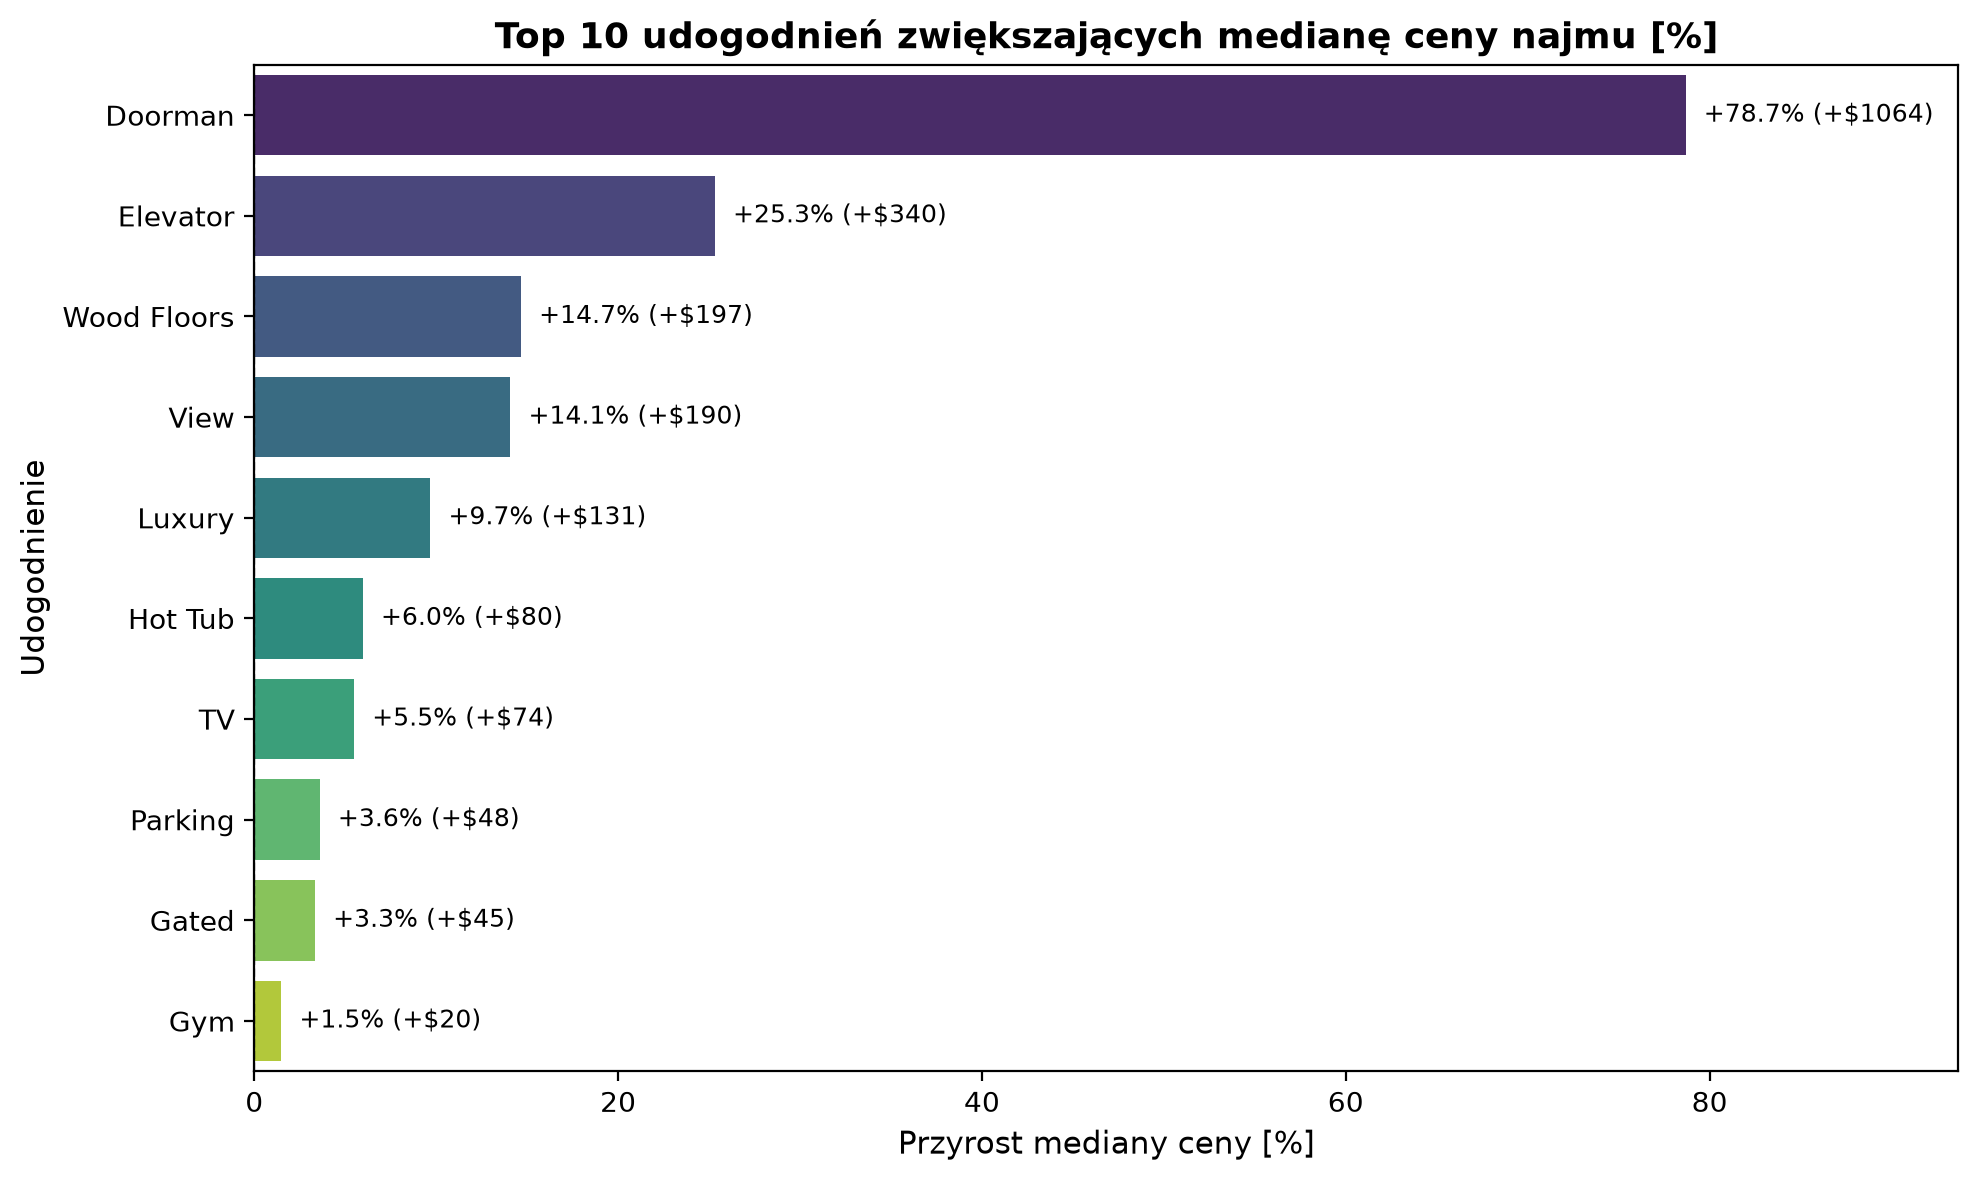

In [ ]:
# Pobranie kolumn z zakresu w pliku
istniejace = df.loc[:, 'AC':'Wood Floors'].columns.tolist()
# korzystamy z macierzy binarnej i sprawdzamy udogodnienia 1 znaczy ze wystepuja 0 ze nie wystepuja
wyniki = []

for feature in istniejace:
    mediana_z = df[df[feature] == 1]['price'].median()
    mediana_bez = df[df[feature] == 0]['price'].median()
    srednia_z = df[df[feature] == 1]['price'].mean()
    srednia_bez = df[df[feature] == 0]['price'].mean()
    liczba_z = (df[feature] == 1).sum()
    
    roznica_mediana = mediana_z - mediana_bez
    procent_mediana = (roznica_mediana / mediana_bez) * 100
    # Tworzymy tabele z wynikami
    wyniki.append({
        'Udogodnienie': feature,
        'Liczba_ofert': liczba_z,
        'Udzial_Pct': (liczba_z / len(df)) * 100,
        'Mediana_Z': mediana_z,
        'Mediana_Bez': mediana_bez,
        'Roznica_USD': roznica_mediana,
        'Wzrost_Mediany_Pct': procent_mediana,
        'Srednia_Z': srednia_z,
        'Srednia_Bez': srednia_bez
    })
# Na tym etapie sortujemy wartości malejąco i pokazujemy tylko top 10
df_analiza = pd.DataFrame(wyniki).sort_values(by='Wzrost_Mediany_Pct', ascending=False)


print(" 10 udogodnien pod wzgledem wplywu na cene ")
print(df_analiza[['Udogodnienie', 'Liczba_ofert', 'Mediana_Z', 'Mediana_Bez', 'Roznica_USD', 'Wzrost_Mediany_Pct']].head(10).to_string(index=False))

# Część tworzenia wykresów zaczynamy od okreslenia wielkosci i zakresu danych
plt.figure(figsize=(10, 6))
top_10 = df_analiza.head(10)
# Przypisujemy wartości do osi
sns.barplot(
    data=top_10, 
    x='Wzrost_Mediany_Pct', 
    y='Udogodnienie', 
    palette='viridis'
)
# Nazywamy osie i wykres
plt.title('Top 10 udogodnień zwiększających medianę ceny najmu [%]', fontsize=13, fontweight='bold')
plt.xlabel('Przyrost mediany ceny [%]', fontsize=11)
plt.ylabel('Udogodnienie', fontsize=11)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
# A tu mały bajer tworzymy koło słupków odpowiadajace im wartości
for idx, row in top_10.reset_index(drop=True).iterrows():
    val = row['Wzrost_Mediany_Pct']
    diff = row['Roznica_USD']
    plt.text(val + 1.0, idx, f"+{val:.1f}% (+${diff:.0f})", va='center', fontsize=9)

plt.xlim(0, top_10['Wzrost_Mediany_Pct'].max() + 15)
plt.tight_layout()
plt.show()